# 11 — Macierz transferu 3×3 (HerBERT)

HerBERT-base fine-tune na każdym z TW/GO/CE (podpróbkowane do N=min, jak w wersji klasycznej), ewaluacja na każdym zbiorze test. Progi strojone na val domeny **treningowej**; test nietknięty. Ważona strata (pos_weight) per zbiór.

In [ ]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd, torch, torch.nn.functional as F
import matplotlib.pyplot as plt, seaborn as sns
from scipy.special import expit
from sklearn.metrics import f1_score
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments,
                          Trainer, DataCollatorWithPadding, EarlyStoppingCallback)
from thesis_lib import optimal_thresholds as opt_thresholds
warnings.filterwarnings("ignore"); sns.set_theme(style="whitegrid"); plt.rcParams["savefig.dpi"]=300

EMOTIONS=["radość","smutek","zaufanie","wstręt","strach","gniew","przeczuwanie","zdziwienie"]
RANDOM_STATE=42; torch.manual_seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)
PROCESSED_DIR=Path("../data/processed"); RESULTS_DIR=Path("../data/results")
FIGURES_DIR=Path("../figures"); HF_OUT=Path("../data/transformers")
MODEL="allegro/herbert-base-cased"; device="cuda" if torch.cuda.is_available() else "cpu"
tok=AutoTokenizer.from_pretrained(MODEL)

def load(split_name, txtcol):
    out={}
    for sp in ["train","val","test"]:
        d=pd.read_csv(PROCESSED_DIR/f"{split_name}_{sp}.csv"); d[txtcol]=d[txtcol].fillna("")
        out[sp]={"text":d[txtcol].tolist(),"y":d[EMOTIONS].values}
    return out

DATA={"TW":load("twitteremo","tekst"),"GO":load("go_emotions","text_pl"),"CE":load("clarin_emo","tekst")}
N_SUB=min(len(DATA[d]["train"]["y"]) for d in DATA)
print("device",device,"| N_SUB",N_SUB)

In [ ]:
def make_ds(text,y):
    d=Dataset.from_dict({"text":text,"labels":y.astype("float32").tolist()})
    return d.map(lambda b: tok(b["text"],truncation=True,max_length=128),batched=True,remove_columns=["text"])

class WTrainer(Trainer):
    def __init__(self,*a,pos_weight=None,**k): super().__init__(*a,**k); self.pos_weight=pos_weight
    def compute_loss(self,model,inputs,return_outputs=False,**kw):
        labels=inputs.pop("labels"); out=model(**inputs)
        loss=F.binary_cross_entropy_with_logits(out.logits.float(),labels.float(),
            pos_weight=self.pos_weight.to(out.logits.device) if self.pos_weight is not None else None)
        return (loss,out) if return_outputs else loss

@torch.no_grad()
def predict_proba(trainer,text):
    ds=make_ds(text,np.zeros((len(text),len(EMOTIONS))))
    return expit(trainer.predict(ds).predictions)

In [3]:
rng=np.random.default_rng(RANDOM_STATE)
def train_on(dom, epochs=3):
    tr=DATA[dom]["train"]
    idx=rng.choice(len(tr["y"]),size=N_SUB,replace=False)
    text=[tr["text"][i] for i in idx]; y=tr["y"][idx]
    pos=y.sum(0); neg=len(y)-pos
    pw=torch.tensor(np.clip(neg/np.maximum(pos,1),1.0,10.0),dtype=torch.float32)
    model=AutoModelForSequenceClassification.from_pretrained(
        MODEL,num_labels=len(EMOTIONS),problem_type="multi_label_classification")
    args=TrainingArguments(output_dir=str(HF_OUT/f"tr3x3_{dom}"),eval_strategy="epoch",
        save_strategy="epoch",save_total_limit=1,load_best_model_at_end=True,
        metric_for_best_model="f1_macro",greater_is_better=True,per_device_train_batch_size=8,
        per_device_eval_batch_size=32,gradient_accumulation_steps=2,gradient_checkpointing=True,
        num_train_epochs=epochs,learning_rate=2e-5,warmup_ratio=0.1,weight_decay=0.01,
        fp16=torch.cuda.is_available(),logging_steps=100,report_to="none",seed=RANDOM_STATE)
    def cm(p): return {"f1_macro":f1_score(p.label_ids.astype(int),(expit(p.predictions)>=0.5).astype(int),average="macro",zero_division=0)}
    tr_obj=WTrainer(model=model,args=args,train_dataset=make_ds(text,y),
        eval_dataset=make_ds(DATA[dom]["val"]["text"],DATA[dom]["val"]["y"]),
        data_collator=DataCollatorWithPadding(tok),compute_metrics=cm,pos_weight=pw,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
    tr_obj.train()
    # progi na val domeny treningowej
    thr=opt_thresholds(DATA[dom]["val"]["y"],predict_proba(tr_obj,DATA[dom]["val"]["text"]))
    return tr_obj,thr

In [4]:
rows=[]; M=pd.DataFrame(index=list(DATA),columns=list(DATA),dtype=float)
for trd in DATA:
    print(f"\n######## TRAIN on {trd} ########",flush=True)
    trainer,thr=train_on(trd)
    for evd in DATA:
        proba=predict_proba(trainer,DATA[evd]["test"]["text"])
        pred=(proba>=thr).astype(int)
        f1m=f1_score(DATA[evd]["test"]["y"],pred,average="macro",zero_division=0)
        M.loc[trd,evd]=f1m
        rows.append({"train":trd,"eval":evd,"f1_macro":round(f1m,3),
                     "setup":f"{trd} → {evd}"+(" (in-domain)" if trd==evd else " (transfer)")})
        print(f"  eval {evd}: F1-Macro={f1m:.3f}")
    del trainer; torch.cuda.empty_cache()
cd=pd.DataFrame(rows); cd.to_csv(RESULTS_DIR/"exp_transfer_matrix_3x3_herbert.csv",index=False)
M.to_csv(RESULTS_DIR/"transfer_matrix_3x3_herbert.csv")
print("\nMacierz HerBERT (wiersz=train, kolumna=eval.test):"); display(M.round(3))


######## TRAIN on TW ########


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 38926.71it/s]


BertForSequenceClassification LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.sso.sso_relationship.bias              | UNEXPECTED | 
cls.sso.sso_relationship.weight            | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly i

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

  eval GO: F1-Macro=0.260


Map:   0%|          | 0/1256 [00:00<?, ? examples/s]

Map: 100%|██████████| 1256/1256 [00:00<00:00, 13767.38 examples/s]

  eval CE: F1-Macro=0.661

Macierz HerBERT (wiersz=train, kolumna=eval.test):


,TW,GO,CE
TW,0.493,0.290,0.288
GO,0.246,0.463,0.311
CE,0.329,0.260,0.661


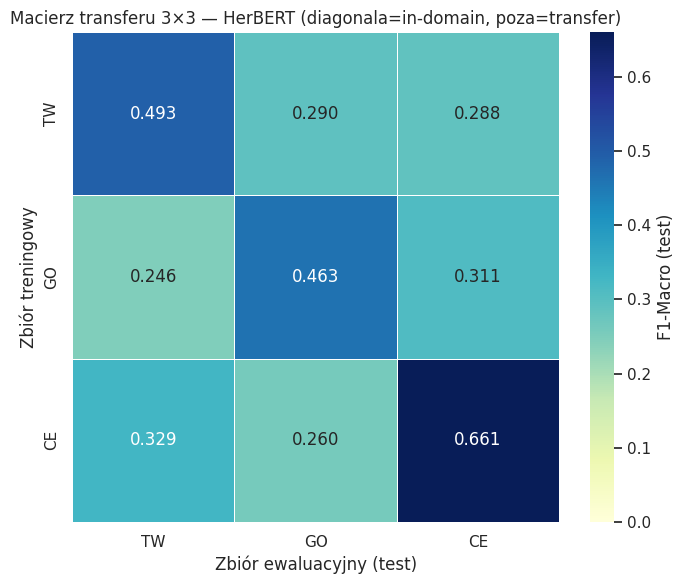

# Macierz transferu 3×3 (HerBERT) — wnioski

- Średnia in-domain (diagonala) = 0.539 | średni transfer (poza) = 0.287 | spadek = +0.251.
- Porównanie z modelem klasycznym (03c): czy transformer transferuje LEPIEJ między domenami,
  czy załamanie jest tak samo silne? (klasyczny: diag~0.45 vs transfer~0.20).



In [5]:
fig,ax=plt.subplots(figsize=(7,6))
sns.heatmap(M.astype(float),annot=True,fmt=".3f",cmap="YlGnBu",linewidths=0.5,
            cbar_kws={"label":"F1-Macro (test)"},vmin=0,vmax=float(np.nanmax(M.values)),ax=ax)
ax.set_xlabel("Zbiór ewaluacyjny (test)"); ax.set_ylabel("Zbiór treningowy")
ax.set_title("Macierz transferu 3×3 — HerBERT (diagonala=in-domain, poza=transfer)")
plt.tight_layout(); plt.savefig(FIGURES_DIR/"exp_transfer_matrix_3x3_herbert.pdf",bbox_inches="tight"); plt.show()

diag=np.diag(M.values.astype(float)).mean(); off=M.values.astype(float)[~np.eye(3,dtype=bool)].mean()
